# Exploratory Structural Consistency Analysis
## Taxonomy Topological Map (Gower+UMAP)

### Feature Matrix

In [ ]:
import pandas as pd

# ==============================================================================
# SECTION 1: DATASET
# ==============================================================================
records = [
    # (
    #     'Technique',
    #     'Category',
    #     'Mechanism',
    #     'Goal',
    #     'Data',
    #     'Persistence',
    #     'Scope',
    #     'Model Type'
    # ),
    (
        'Training',
        'Reference Baseline',
        'Param. Upd.',
        'Build Capab.',
        'Large Labeled',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Whole',
        '{ML, DL, FM, LLM, MLLM}'
    ),
    (
        'FT (full)',
        'Knowledge Transfer and Task Specialization',
        'Param. Upd.',
        'Task Spec.',
        'Large Labeled',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Whole',
        '{DL, FM, LLM, MLLM}'
    ),
    (
        'FT (partial)',
        'Knowledge Transfer and Task Specialization',
        'Param. Upd.',
        'Task Spec.',
        'Small Labeled',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Part.',
        '{DL, FM, LLM, MLLM}'
    ),
    (
        'PEFT (LoRA, adapters)',
        'Knowledge Transfer and Task Specialization',
        'Param. Upd.',
        '{Task Spec., Comp. Eff.}',
        'Small Labeled',
        '{Sched. Perm., Ad-hoc Perm.}',
        '{Part., Modular}',
        '{DL, FM, LLM, MLLM}'
    ),
    ('ReFT',
     'Knowledge Transfer and Task Specialization',
     'Param. Upd.', 'Task Spec.', 'Small Labeled',
     '{Sched. Perm., Ad-hoc Perm.}', 'Modular', '{LLM, MLLM}'),
    (
        'DA',
        'Knowledge Transfer and Task Specialization',
        'Param. Upd.',
        'Dist. Gap Bridging',
        '{Unlabeled, Small Labeled}',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Part.',
        '{DL, FM}'
    ),
    (
        'FSL',
        'Knowledge Transfer and Task Specialization',
        'Param. Upd.',
        'Task Spec.',
        '{Small Labeled, Few Demo.}',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Part.',
        '{DL, FM}'
    ),
    (
        'Retraining',
        'Temporal Adaptation and Maintenance',
        'Param. Upd.',
        'Drift Remed.',
        'Seq./Inc.',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Whole',
        '{ML, DL, FM, LLM, MLLM}'
    ),
    (
        'CL',
        'Temporal Adaptation and Maintenance',
        'Param. Upd.',
        'Cont. Adapt.',
        'Seq./Inc.',
        '{Bound. Cumul., Unbound. Cumul.}',
        'Part.',
        '{DL, FM, LLM, MLLM}'
    ),
    (
        'TIL',
        'Temporal Adaptation and Maintenance',
        'Param. Upd.',
        'Cont. Adapt.',
        'Seq./Inc.',
        'Bound. Cumul.',
        '{Part., Modular}',
        '{DL, FM}'
    ),
    (
        'DIL',
        'Temporal Adaptation and Maintenance',
        'Param. Upd.',
        '{Cont. Adapt., Drift Remed.}',
        'Seq./Inc.',
        'Unbound. Cumul.',
        '{Part., Whole}',
        '{DL, FM}'
    ),
    (
        'SFT',
        'Alignment, Reasoning, and Trustworthiness',
        'Param. Upd.',
        '{Task Spec., Align., Safety}',
        'Instr.-Resp. Corpus',
        '{Sched. Perm., Ad-hoc Perm.}',
        '{Part., Whole}',
        '{LLM, MLLM}'
    ),
    (
        'RLHF (LLM Alignment)',
        'Alignment, Reasoning, and Trustworthiness',
        'Param. Upd.',
        '{Align., Safety}',
        'Pref. Pairs',
        '{Sched. Perm., Ad-hoc Perm.}',
        '{Part., Whole, Surrog. Model}',
        '{LLM, MLLM}'
    ),
    (
        'DPO',
        'Alignment, Reasoning, and Trustworthiness',
        'Param. Upd.',
        '{Align., Safety}',
        'Pref. Pairs',
        '{Sched. Perm., Ad-hoc Perm.}',
        '{Part., Whole}',
        '{LLM, MLLM}'
    ),
    (
        'RLAIF/CAI',
        'Alignment, Reasoning, and Trustworthiness',
        'Param. Upd.',
        '{Align., Safety}',
        'Constitution-Deriv.',
        '{Sched. Perm., Ad-hoc Perm.}',
        '{Part., Whole}',
        '{LLM, MLLM}'
    ),
    (
        'RLVR/GRPO',
        'Alignment, Reasoning, and Trustworthiness',
        'Param. Upd.',
        'Reas.',
        'Verif. Task',
        '{Sched. Perm., Ad-hoc Perm.}',
        '{Part., Whole}',
        '{LLM, MLLM}'
    ),
    (
        'Adversarial Training',
        'Alignment, Reasoning, and Trustworthiness',
        'Param. Upd.',
        'Rob.',
        'Large Labeled',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Whole',
        '{DL, FM, LLM}'
    ),
    (
        'LP',
        'Alignment, Reasoning, and Trustworthiness',
        'Param. Upd.',
        'Expl.',
        'Small Labeled',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Modular',
        '{DL, FM, LLM, MLLM}'
    ),
    (
        'LEACE',
        'Alignment, Reasoning, and Trustworthiness',
        'Param. Comp.',
        'Fair.',
        'Small Labeled',
        'Ad-hoc Perm.',
        'Part.',
        '{DL, FM, LLM, MLLM}'
    ),
    (
        'Meta-Learning',
        'Training Strategies',
        'Param. Upd.',
        'Task Spec.',
        'Task Dist.',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Part.',
        '{DL, FM}'
    ),
    (
        'MTL',
        'Training Strategies',
        'Param. Upd.',
        'Task Spec.',
        'Task Dist.',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Whole',
        '{DL, FM, LLM, MLLM}'
    ),
    (
        'Self-Play',
        'Training Strategies',
        'Param. Upd.',
        '{Task Spec., Align., Reas.}',
        'Environment-Deriv.',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Whole',
        '{DL, LLM}'
    ),
    (
        'Curriculum Learning',
        'Training Strategies',
        'Pipe.-Med.',
        'Task Spec.',
        'Pipe.-Dep.',
        'Pipe.-Dep.',
        'Pipe.-Dep.',
        '{ML, DL, FM, LLM, MLLM}'
    ),
    (
        'Active Learning',
        'Training Strategies',
        'Pipe.-Med.',
        '{Task Spec., Dist. Gap Bridging}',
        'Pipe.-Dep.',
        'Pipe.-Dep.',
        'Pipe.-Dep.',
        '{ML, DL, FM, LLM, MLLM}'
    ),
    (
        'Data Augmentation',
        'Data-Centric and Privacy-Preserving Methods',
        'Pipe.-Med.',
        '{Task Spec., Rob.}',
        'Pipe.-Dep.',
        'Pipe.-Dep.',
        'Pipe.-Dep.',
        '{ML, DL, FM, LLM, MLLM}'
    ),
    (
        'Semi-SL',
        'Data-Centric and Privacy-Preserving Methods',
        'Pipe.-Med.',
        'Task Spec.',
        '{Unlabeled, Small Labeled}',
        'Pipe.-Dep.',
        'Pipe.-Dep.',
        '{ML, DL, FM, LLM, MLLM}'
    ),
    (
        'SSL/CPT',
        'Data-Centric and Privacy-Preserving Methods',
        'Param. Upd.',
        '{Capab. Ext., Dist. Gap Bridging}',
        'Unlabeled',
        '{Unbound. Cumul., Sched. Perm.}',
        '{Part., Whole}',
        '{DL, FM, LLM, MLLM}'
    ),
    ('DP-FT',
     'Data-Centric and Privacy-Preserving Methods',
     'Param. Upd.', 'Priv. Preserv.', '{Large Labeled, Small Labeled}',
     '{Sched. Perm., Ad-hoc Perm.}', '{Part., Whole}', '{DL, FM, LLM, MLLM}'),
    (
        'FL',
        'Data-Centric and Privacy-Preserving Methods',
        'Param. Upd.',
        'Priv. Preserv.',
        'Decent.',
        'Sched. Perm.',
        'Dist.',
        '{ML, DL, FM, LLM, MLLM}'
    ),
    (
        'KD',
        'Efficiency and Composition',
        'Cross-Model Transf.',
        'Comp. Eff.',
        'Teacher-Deriv.',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Surrog. Model',
        '{DL, FM, LLM, MLLM}'
    ),
    (
        'Model Compression',
        'Efficiency and Composition',
        'Param. Compres.',
        'Comp. Eff.',
        '{Unlabeled, Param.-Only}',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Compress. Artif.',
        '{DL, FM, LLM, MLLM}'
    ),
    (
        'Task Arith. & Model Merging',
        'Efficiency and Composition',
        'Param. Comp.',
        '{Capab. Ext., Comp. Eff.}',
        'Param.-Only',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Fused',
        '{FM, LLM, MLLM}'
    ),
    ('Long-Context Ext.',
     'Efficiency and Composition',
     '{Arch., Param. Upd.}', 'Capab. Ext.', '{Unlabeled, Small Labeled}',
     '{Sched. Perm., Ad-hoc Perm.}', 'Part.', '{FM, LLM, MLLM}'),
    (
        'MoE',
        'Efficiency and Composition',
        '{Arch., Param. Upd.}',
        '{Capab. Ext., Comp. Eff.}',
        '{Unlabeled, Small Labeled}',
        '{Sched. Perm., Ad-hoc Perm.}',
        '{Part., Modular}',
        '{FM, LLM, MLLM}'
    ),
    (
        'PE',
        'Inference-Time Adaptation',
        'Context Inj.',
        '{Knowl. Upd., Behav. Ctrl.}',
        'Zero-Shot',
        '{Sess.-Eph., Ver.-Persist.}',
        'I/O Space',
        '{LLM, MLLM}'
    ),
    (
        'Prompt Learning',
        'Inference-Time Adaptation',
        'Param. Upd.',
        'Task Spec.',
        'Small Labeled',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Part.',
        '{FM, LLM, MLLM}'
    ),
    ('APO',
     'Inference-Time Adaptation',
     'Context Inj.', '{Task Spec., Behav. Ctrl.}', '{Zero-Shot, Few Demo.}',
     'Ver.-Persist.', 'I/O Space', '{LLM, MLLM}'),
    (
        'RAG',
        'Inference-Time Adaptation',
        'Context Inj.',
        'Knowl. Upd.',
        'Ext. Corpus',
        'Ver.-Persist.',
        'I/O Space',
        '{LLM, MLLM}'
    ),
    (
        'ICL',
        'Inference-Time Adaptation',
        'Context Inj.',
        '{Task Spec., Knowl. Upd.}',
        'Few Demo.',
        'Sess.-Eph.',
        'I/O Space',
        '{LLM, MLLM}'
    ),
    (
        'CE',
        'Inference-Time Adaptation',
        'Context Inj.',
        '{Knowl. Upd., Person.}',
        '{Ext. Corpus, User Interact.}',
        'Ver.-Persist.',
        'I/O Space',
        '{LLM, MLLM}'
    ),
    (
        'TTA',
        'Inference-Time Adaptation',
        'Param. Upd.',
        'Drift Remed.',
        'Test-Only',
        'Transient',
        '{Part., Whole}',
        '{DL, FM}'
    ),
    (
        'Test-Time Compute Scaling',
        'Inference-Time Adaptation',
        'Infer.-Time Search',
        'Reas.',
        'Zero-Shot',
        'Sess.-Eph.',
        'I/O Space',
        '{LLM, MLLM}'
    ),
    (
        'Calibration',
        'Calibration, Personalization, and Multimodal Adaptation',
        'Param. Upd.',
        'Reliab.',
        '{Unlabeled, Small Labeled}',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Modular',
        '{ML, DL, FM, LLM, MLLM}'
    ),
    (
        'Cross-Modal Alignment',
        'Calibration, Personalization, and Multimodal Adaptation',
        'Param. Upd.',
        'Capab. Ext.',
        'Pair. Multimod.',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Part.',
        '{FM, MLLM}'
    ),
    (
        'Modality-Spec. Adapters',
        'Calibration, Personalization, and Multimodal Adaptation',
        'Param. Upd.',
        '{Capab. Ext., Comp. Eff.}',
        'Pair. Multimod.',
        '{Sched. Perm., Ad-hoc Perm.}',
        'Modular',
        'MLLM'
    ),
    (
        'Multimodal Instr. Tuning',
        'Calibration, Personalization, and Multimodal Adaptation',
        'Param. Upd.',
        '{Capab. Ext., Align.}',
        'Pair. Multimod.',
        '{Sched. Perm., Ad-hoc Perm.}',
        '{Part., Whole}',
        'MLLM'
    ),
    (
        'Machine Unlearning',
        'Knowledge Modification and Activation-Based Adaptation',
        '{Param. Upd., Param. Comp.}',
        '{Rem. Knowl., Priv. Preserv.}',
        'Forget Set Spec.',
        'Ad-hoc Perm.',
        '{Part., Fused}',
        '{DL, FM, LLM, MLLM}'
    ),
    (
        'Knowledge Editing',
        'Knowledge Modification and Activation-Based Adaptation',
        '{Param. Upd., Param. Comp.}',
        'Knowl. Upd.',
        'Small Labeled',
        'Ad-hoc Perm.',
        'Part.',
        '{LLM, MLLM}'
    ),
    (
        'Activation Steering',
        'Knowledge Modification and Activation-Based Adaptation',
        'Act.-Space Manip.',
        '{Align., Safety}',
        '{Unlabeled, Small Labeled}',
        'Transient',
        'Activ.-Space',
        '{LLM, MLLM}'
    ),
]


COLUMNS = ['Technique', 'Family',
           'D1_Mechanism', 'D2_Goal', 'D3_Data', 'D4_Persistence', 'D5_Scope', 'D6_ModelType']
df = pd.DataFrame(records, columns=COLUMNS)
FEATURE_COLS = ['D1_Mechanism', 'D2_Goal', 'D3_Data', 'D4_Persistence', 'D5_Scope', 'D6_ModelType']

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"  Techniques : {len(df)}")
print(f"  Families   : {df['Family'].nunique()}")
print()
for col in FEATURE_COLS:
    vals = sorted(df[col].unique())
    print(f"  {col} ({len(vals)} levels):")
    for v in vals:
        n = (df[col] == v).sum()
        print(f"    [{n:2d}] {v}")
    print()

DATASET SUMMARY
  Techniques : 49
  Families   : 10

  D1_Mechanism (10 levels):
    [ 1] Act.-Space Manip.
    [ 5] Context Inj.
    [ 1] Cross-Model Transf.
    [ 1] Infer.-Time Search
    [ 2] Param. Comp.
    [ 1] Param. Compres.
    [30] Param. Upd.
    [ 4] Pipe.-Med.
    [ 2] {Arch., Param. Upd.}
    [ 2] {Param. Upd., Param. Comp.}

  D2_Goal (29 levels):
    [ 1] Build Capab.
    [ 2] Capab. Ext.
    [ 2] Comp. Eff.
    [ 2] Cont. Adapt.
    [ 1] Dist. Gap Bridging
    [ 2] Drift Remed.
    [ 1] Expl.
    [ 1] Fair.
    [ 2] Knowl. Upd.
    [ 2] Priv. Preserv.
    [ 2] Reas.
    [ 1] Reliab.
    [ 1] Rob.
    [ 9] Task Spec.
    [ 4] {Align., Safety}
    [ 1] {Capab. Ext., Align.}
    [ 3] {Capab. Ext., Comp. Eff.}
    [ 1] {Capab. Ext., Dist. Gap Bridging}
    [ 1] {Cont. Adapt., Drift Remed.}
    [ 1] {Knowl. Upd., Behav. Ctrl.}
    [ 1] {Knowl. Upd., Person.}
    [ 1] {Rem. Knowl., Priv. Preserv.}
    [ 1] {Task Spec., Align., Reas.}
    [ 1] {Task Spec., Align., Safety}
  

### Analyses (Gower + UMAP + Silhouette)

In [ ]:
#!/usr/bin/env python3
"""
==============================================================================
Post-Training Techniques in Machine Learning:
A Six-Dimensional Taxonomy Bridging Technical Practice and Regulatory Science
==============================================================================

INSTALL REQUIREMENTS:
  pip install pandas numpy scikit-learn matplotlib seaborn umap-learn prince
  (gower package optional — we implement it manually below for reliability)

==============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('fig', exist_ok=True)

# ==============================================================================
# SECTION 2: GOWER / CATEGORICAL DISTANCE MATRIX
# ==============================================================================

def categorical_gower_distance(df: pd.DataFrame) -> np.ndarray:
    """
    Computes pairwise Gower distance using set-based Jaccard distance for all columns.
    All column values are treated as sets; plain strings become singleton sets.
    Supports both 'A' and '{A, B}' notation.
    """
    def parse_set(val) -> frozenset:
        if isinstance(val, (set, frozenset)):
            return frozenset(val)
        if isinstance(val, list):
            return frozenset(val)
        if pd.isna(val):
            return frozenset()
        s = str(val).strip()
        if s.startswith('{') and s.endswith('}'):
            s = s[1:-1]
        return frozenset(item.strip() for item in s.split(',') if item.strip())

    parsed = df.apply(lambda col: col.map(parse_set))

    n, q = len(df), len(df.columns)
    dist = np.zeros((n, n), dtype=np.float64)

    for i in range(n):
        for j in range(i + 1, n):
            total = 0.0
            for col in df.columns:
                set_i = parsed.iloc[i][col]
                set_j = parsed.iloc[j][col]
                union = len(set_i | set_j)
                jaccard = 1.0 - len(set_i & set_j) / union if union > 0 else 0.0
                total += jaccard
            dist[i, j] = dist[j, i] = total / q

    return dist

print("Computing pairwise Gower distance matrix …")
dist_matrix = categorical_gower_distance(df[FEATURE_COLS])
print(f"  Shape  : {dist_matrix.shape}")
print(f"  Min    : {dist_matrix[dist_matrix > 0].min():.4f}  "
      f"(minimum non-zero distance between any two techniques)")
print(f"  Max    : {dist_matrix.max():.4f}")
print(f"  Mean   : {dist_matrix.mean():.4f}")
print()


# ==============================================================================
# SECTION 3: EMBEDDINGS
# ==============================================================================

# ------------------------------------------------------------------
# 3a. UMAP with precomputed Gower distance — best for small N
# ------------------------------------------------------------------
import umap as umap_module # pip install umap-learn

n_neighbors = 7 # √40 ≈ 6.3; use 7 — captures local structure
min_dist = 0.25 # moderate spread; tighter than default 0.1
print(f"Fitting UMAP (Gower distance, n_neighbors={n_neighbors}) …")
reducer = umap_module.UMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    metric='precomputed',
    random_state=42,
    n_epochs=500,
)
umap_coords = reducer.fit_transform(dist_matrix)
df['umap_1'] = umap_coords[:, 0]
df['umap_2'] = umap_coords[:, 1]
print("UMAP embedding complete.")

# ==============================================================================
# SECTION 4: QUANTITATIVE VALIDATION — Silhouette Score
# ==============================================================================
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
family_labels = le.fit_transform(df['Family'])

print()
print("=" * 70)
print("SILHOUETTE SCORES  (range –1 to +1; >0.2 = meaningful clustering)")
print("=" * 70)

sil_raw = silhouette_score(dist_matrix, family_labels, metric='precomputed')
print(f"  Raw Gower distance (ground truth) : {sil_raw:+.4f}")

sil_umap = silhouette_score(umap_coords, family_labels)
print(f"  UMAP embedding                     : {sil_umap:+.4f}")

# ==============================================================================
# SECTION 5: FAMILY INTERNAL PROFILE ANALYSIS
# ==============================================================================
print()
print("=" * 70)
print("FAMILY INTERNAL PROFILE DIVERSITY")
print("=" * 70)
print(f"{'Family':<42} {'N':>3} {'Unique profiles':>15} {'Mean intra-dist':>16}")
print("-" * 78)

for fam in sorted(df['Family'].unique()):
    idx = df.index[df['Family'] == fam].tolist()
    grp = df.loc[idx, FEATURE_COLS]
    n_unique = grp.drop_duplicates().shape[0]
    # Mean pairwise intra-family Gower distance
    if len(idx) > 1:
        sub_dist = dist_matrix[np.ix_(idx, idx)]
        upper = sub_dist[np.triu_indices(len(idx), k=1)]
        mean_dist = upper.mean()
    else:
        mean_dist = 0.0
    short_fam = fam[:42]
    print(f"  {short_fam:<42} {len(idx):>3} {n_unique:>15} {mean_dist:>14.4f}")

# ==============================================================================
# SECTION 6: VISUALIZATION Functions
# ==============================================================================

FAMILIES_ORDERED = sorted(df['Family'].unique())
PALETTE = sns.color_palette("tab10", n_colors=len(FAMILIES_ORDERED))
FAMILY_COLOR = dict(zip(FAMILIES_ORDERED, PALETTE))

MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X','<', '>']
FAMILY_MARKER = dict(zip(FAMILIES_ORDERED, MARKERS))


def plot_panel(ax, x_col, y_col, title, df, show_legend=False):
    for fam in FAMILIES_ORDERED:
        grp = df[df['Family'] == fam]
        ax.scatter(
            grp[x_col], grp[y_col],
            color=FAMILY_COLOR[fam],
            marker=FAMILY_MARKER[fam],
            s=130, alpha=0.88,
            edgecolors='white', linewidths=0.6,
            zorder=3
        )
    # Technique labels
    for _, row in df.iterrows():
        ax.annotate(
            row['Technique'],
            xy=(row[x_col], row[y_col]),
            xytext=(5, 4),
            textcoords='offset points',
            fontsize=5.8, alpha=0.82,
            zorder=4
        )
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel(x_col.replace('_', ' '), fontsize=8)
    ax.set_ylabel(y_col.replace('_', ' '), fontsize=8)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.tick_params(labelsize=7)
    return ax

Computing pairwise Gower distance matrix …
  Shape  : (49, 49)
  Min    : 0.0417  (minimum non-zero distance between any two techniques)
  Max    : 1.0000
  Mean   : 0.6847

Fitting UMAP (Gower distance, n_neighbors=7) …
UMAP embedding complete.

SILHOUETTE SCORES  (range –1 to +1; >0.2 = meaningful clustering)
  Raw Gower distance (ground truth) : +0.0173
  UMAP embedding                     : -0.0346

FAMILY INTERNAL PROFILE DIVERSITY
Family                                       N Unique profiles  Mean intra-dist
------------------------------------------------------------------------------
  Alignment, Reasoning, and Trustworthiness    8               8         0.4965
  Calibration, Personalization, and Multimod   4               4         0.4269
  Data-Centric and Privacy-Preserving Method   5               5         0.6756
  Efficiency and Composition                   5               5         0.5472
  Inference-Time Adaptation                    8               8         0.6463


## Gower distance heatmap

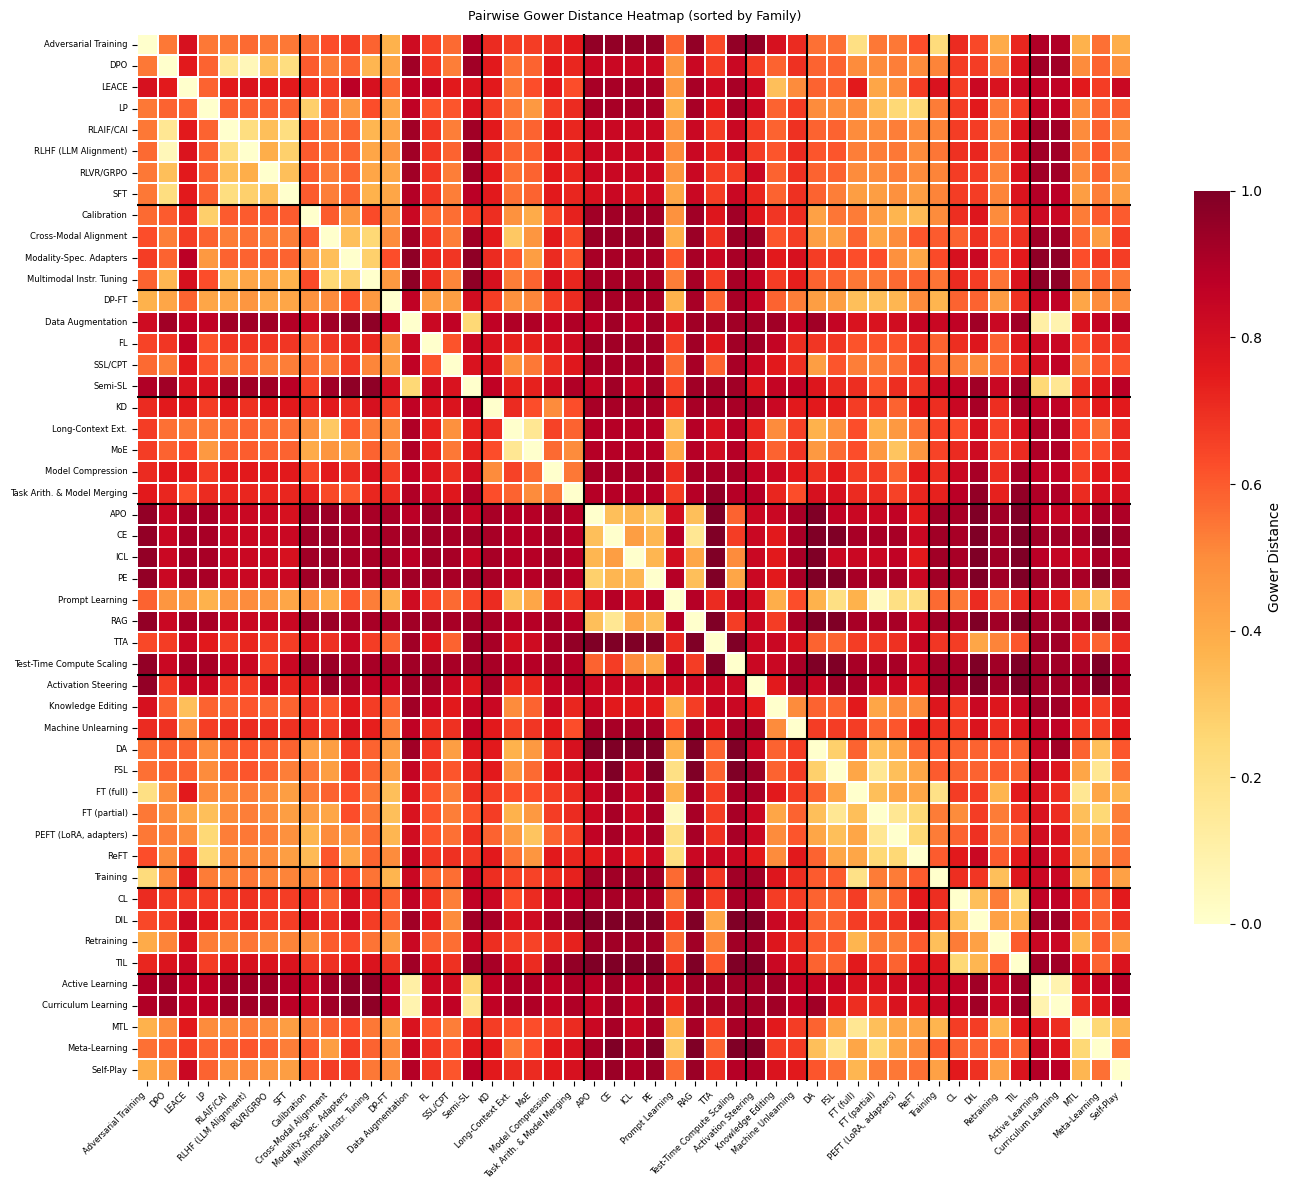

Saved: fig/gower_heatmap.png


In [ ]:
# ── Figure 3: Gower distance heatmap (family-sorted) ─────────────────────────
fig3, ax3 = plt.subplots(figsize=(14, 12))

# Sort techniques by family for block-diagonal structure
df_sorted = df.sort_values(['Family', 'Technique']).reset_index(drop=True)
sorted_idx = df_sorted.index.tolist()
orig_idx = [df[df['Technique'] == t].index[0] for t in df_sorted['Technique']]
dist_sorted = dist_matrix[np.ix_(orig_idx, orig_idx)]

sns.heatmap(dist_sorted, ax=ax3,
            xticklabels=df_sorted['Technique'],
            yticklabels=df_sorted['Technique'],
            cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Gower Distance', 'shrink': 0.7})

ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=6)
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0, fontsize=6)

# Draw family boundary lines
family_sizes = df_sorted.groupby('Family', sort=False).size()
boundaries = np.cumsum([
    family_sizes[f] for f in df_sorted['Family'].unique()
])[:-1]
for b in boundaries:
    ax3.axhline(b, color='black', linewidth=1.5)
    ax3.axvline(b, color='black', linewidth=1.5)

ax3.set_title(
    'Pairwise Gower Distance Heatmap (sorted by Family)',
    fontsize=9, pad=10
)
plt.tight_layout()
fig3.savefig('fig/gower_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig/gower_heatmap.png")

## UMAP

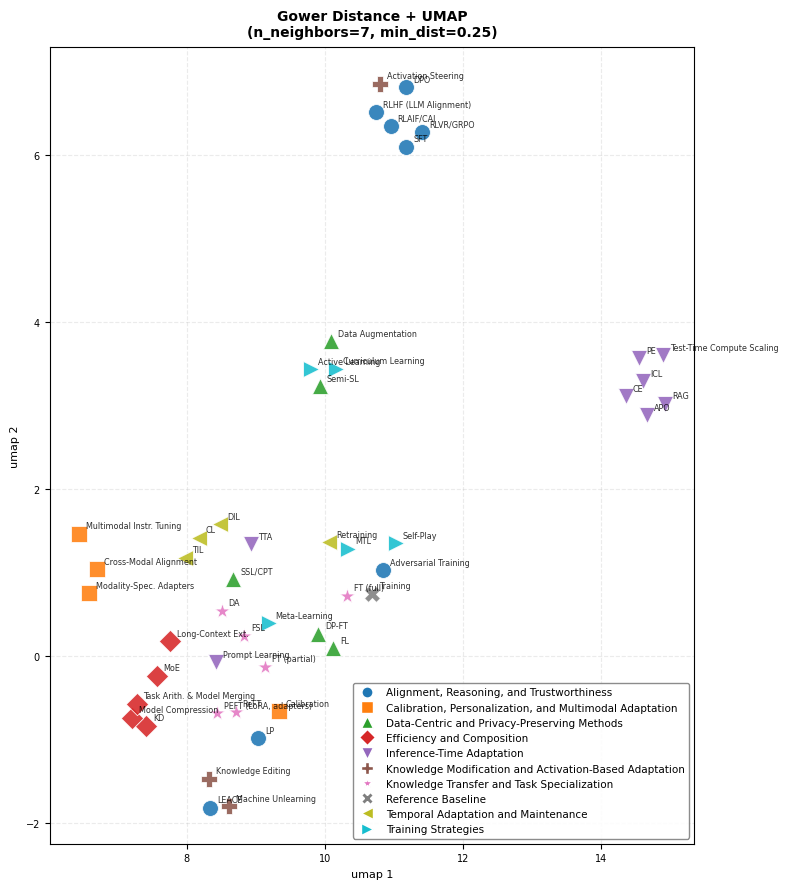

Saved: fig/GowerUmap.png


In [ ]:
# ── Figure 1: UMAP ──────────────
fig, axes = plt.subplots(1, 1, figsize=(8 * 1, 9))

plot_panel(axes, 'umap_1', 'umap_2', f'Gower Distance + UMAP\n(n_neighbors={n_neighbors}, min_dist={min_dist})', df)

# Legend
legend_markers = [
    plt.Line2D([0], [0], marker=FAMILY_MARKER[f], color='w',
               markerfacecolor=FAMILY_COLOR[f], markersize=8, label=f)
    for f in FAMILIES_ORDERED
]
axes.legend(handles=legend_markers, loc='best',
           fontsize=7.5,
           framealpha=0.9, edgecolor='gray')
plt.tight_layout()
fig.savefig('fig/GowerUmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig/GowerUmap.png")

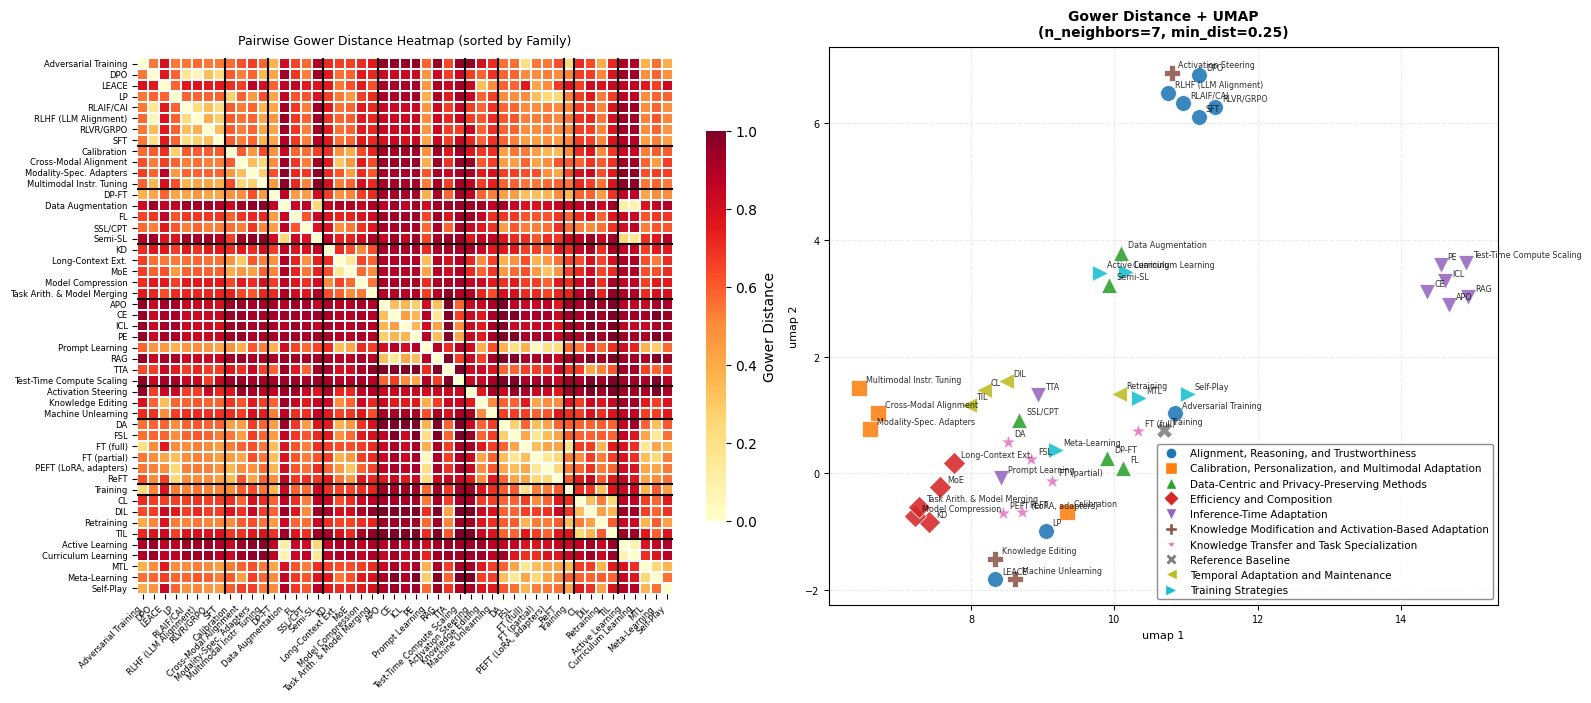

Saved: fig/Gower_Umap.png


In [ ]:
# ── Figure 1: UMAP ──────────────
fig, axes = plt.subplots(1, 2, figsize=(8 * 2, 7))

# ── Figure 3: Gower distance heatmap (family-sorted) ─────────────────────────
ax3 = axes[0]
# Sort techniques by family for block-diagonal structure
df_sorted = df.sort_values(['Family', 'Technique']).reset_index(drop=True)
sorted_idx = df_sorted.index.tolist()
orig_idx = [df[df['Technique'] == t].index[0] for t in df_sorted['Technique']]
dist_sorted = dist_matrix[np.ix_(orig_idx, orig_idx)]

sns.heatmap(dist_sorted, ax=ax3,
            xticklabels=df_sorted['Technique'],
            yticklabels=df_sorted['Technique'],
            cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Gower Distance', 'shrink': 0.7})

ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=6)
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0, fontsize=6)

# Draw family boundary lines
family_sizes = df_sorted.groupby('Family', sort=False).size()
boundaries = np.cumsum([
    family_sizes[f] for f in df_sorted['Family'].unique()
])[:-1]
for b in boundaries:
    ax3.axhline(b, color='black', linewidth=1.5)
    ax3.axvline(b, color='black', linewidth=1.5)

ax3.set_title(
    'Pairwise Gower Distance Heatmap (sorted by Family)',
    fontsize=9, pad=10
)
ax3.set_aspect('equal', adjustable='box') # Make the heatmap square
plt.tight_layout()
# fig3.savefig('fig/gower_heatmap.png', dpi=300, bbox_inches='tight')
# plt.show()
# print("Saved: fig/gower_heatmap.png")

plot_panel(axes[1], 'umap_1', 'umap_2', f'Gower Distance + UMAP\n(n_neighbors={n_neighbors}, min_dist={min_dist})', df)

# Legend
legend_markers = [
    plt.Line2D([0], [0], marker=FAMILY_MARKER[f], color='w',
               markerfacecolor=FAMILY_COLOR[f], markersize=8, label=f)
    for f in FAMILIES_ORDERED
]
axes[1].legend(handles=legend_markers, loc='best',
           fontsize=7.5,
           framealpha=0.9, edgecolor='gray')
plt.tight_layout()
fig.savefig('fig/Gower_Umap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig/Gower_Umap.png")

## Per-dimension UMAP

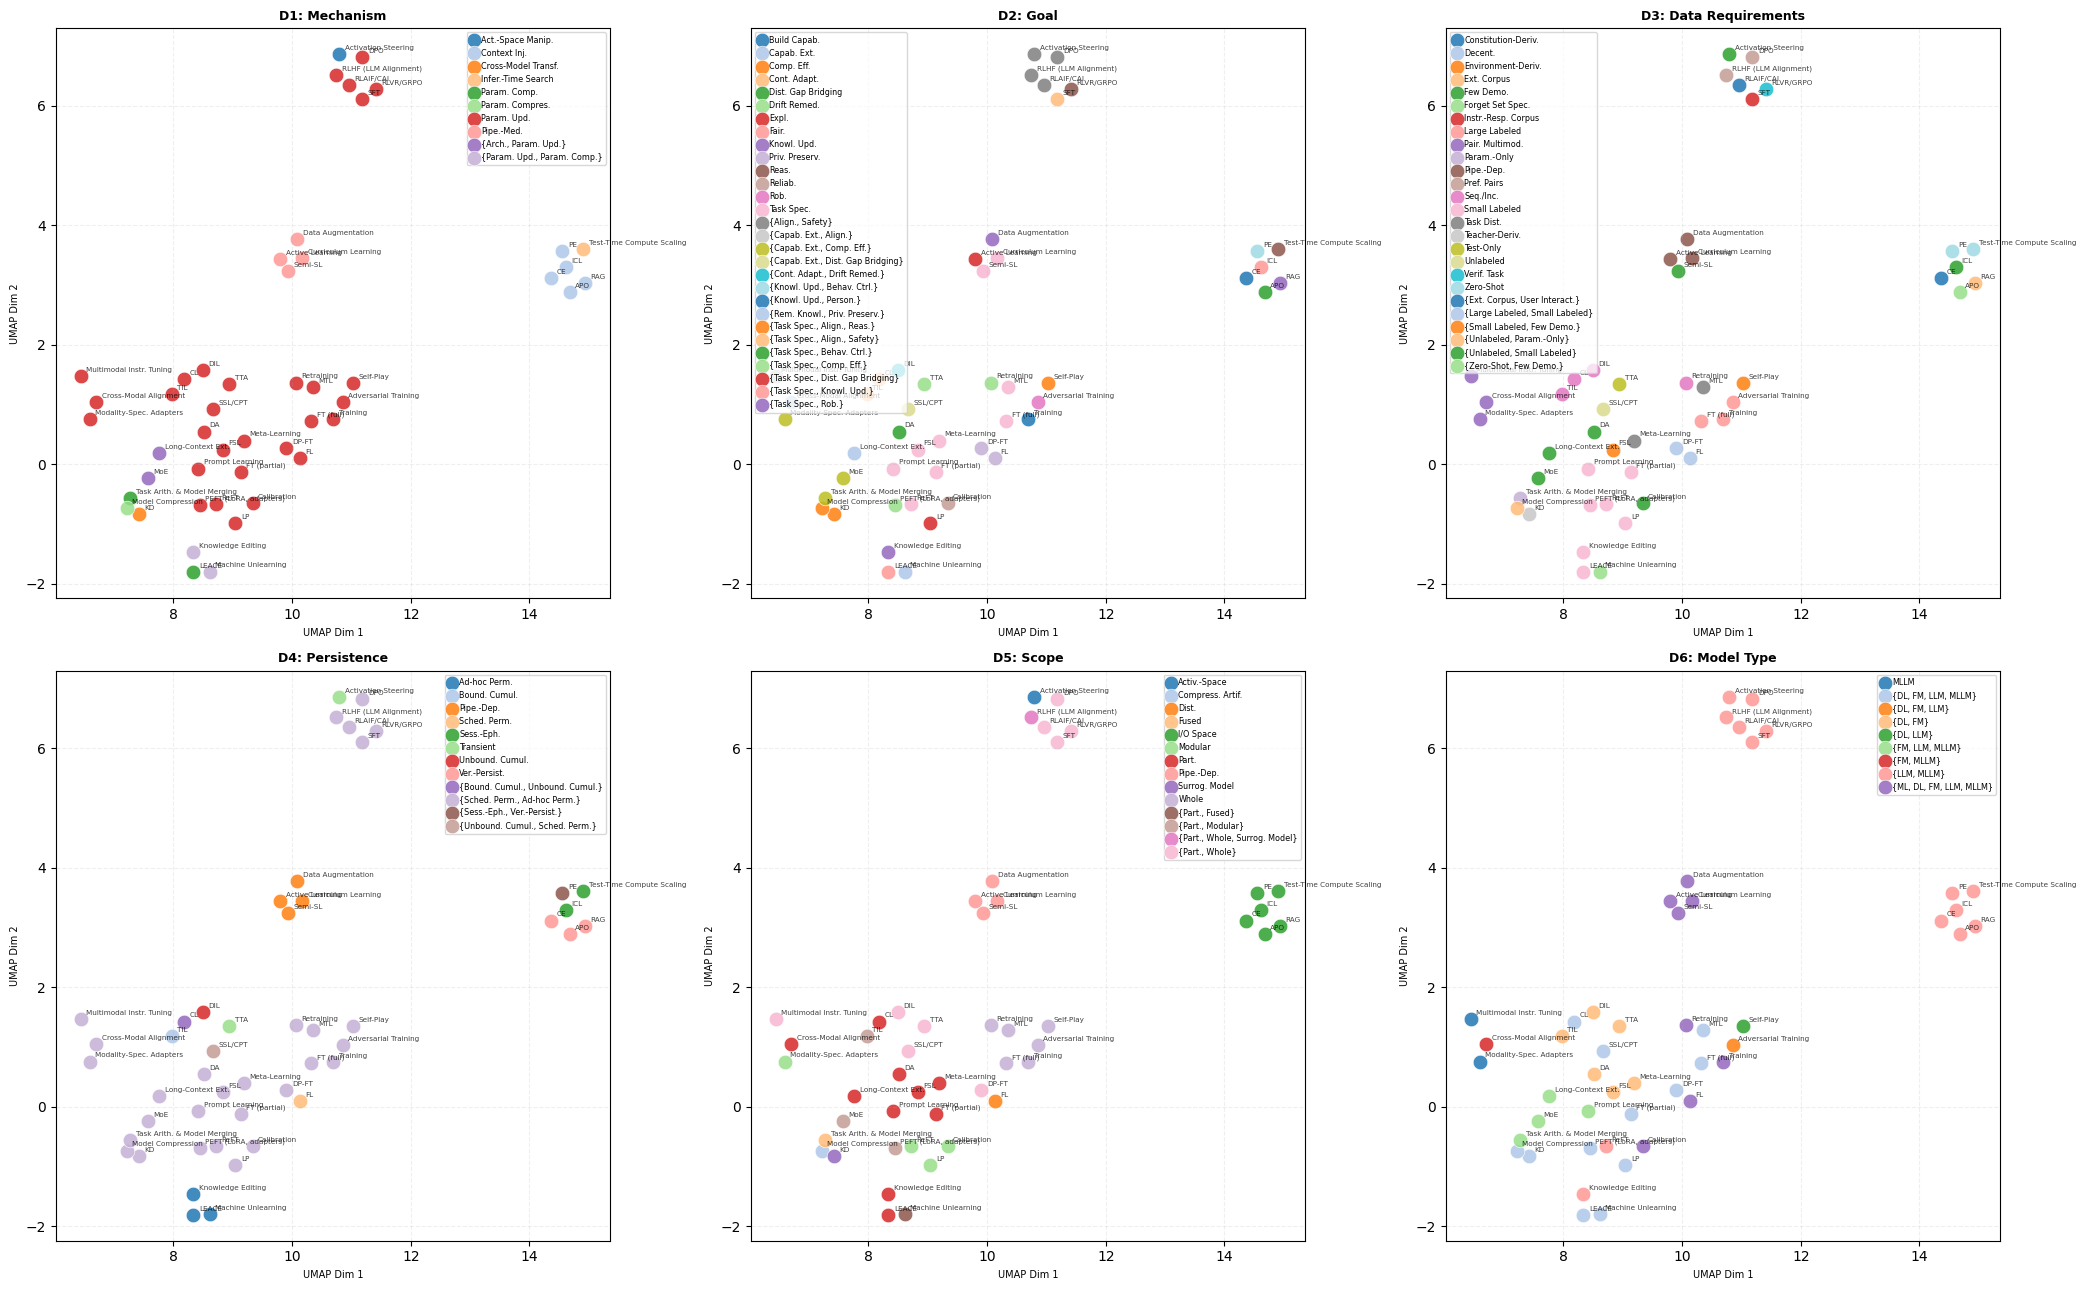

Saved: fig/GowerUmap_perDimension.png


In [ ]:
# ── Figure 2: Per-dimension coloring (shows which dimension drives separation) ──
fig2, axes2 = plt.subplots(2, 3, figsize=(21, 13))
x_col = 'umap_1'
y_col = 'umap_2'
embed_name = 'UMAP'

dim_labels = {
    'D1_Mechanism': 'D1: Mechanism',
    'D2_Goal': 'D2: Goal',
    'D3_Data': 'D3: Data Requirements',
    'D4_Persistence': 'D4: Persistence',
    'D5_Scope': 'D5: Scope',
    'D6_ModelType': 'D6: Model Type',
    'Family': 'Functional Family',
}

for ax, (col, label) in zip(axes2.flat, dim_labels.items()):
    levels = sorted(df[col].unique())
    pal = sns.color_palette("tab20", n_colors=len(levels))
    col_color = dict(zip(levels, pal))

    for lvl in levels:
        grp = df[df[col] == lvl]
        ax.scatter(grp[x_col], grp[y_col],
                   color=col_color[lvl], s=110, alpha=0.85,
                   edgecolors='white', linewidths=0.5, label=lvl)
    for _, row in df.iterrows():
        ax.annotate(row['Technique'],
                    xy=(row[x_col], row[y_col]),
                    xytext=(4, 3), textcoords='offset points',
                    fontsize=5.2, alpha=0.75)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel(f'{embed_name} Dim 1', fontsize=7)
    ax.set_ylabel(f'{embed_name} Dim 2', fontsize=7)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.legend(fontsize=5.8, loc='best', framealpha=0.75,
              handlelength=1, handletextpad=0.4)

# plt.suptitle(
#     f'Taxonomy Embedding ({embed_name} on Gower Distance) — '
#     'Coloured by Each Dimension Independently',
#     fontsize=10, y=1.01
# )
plt.tight_layout()
fig2.savefig('fig/GowerUmap_perDimension.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig/GowerUmap_perDimension.png")